In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import warnings
warnings.filterwarnings("ignore")

In [9]:
data = pd.read_csv("../STOCK MARKET/ADANIPORTS.csv")
data.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


In [10]:
df = data[['Close']]
scaler = MinMaxScaler(feature_range=(0,1))
s_df = scaler.fit_transform(df)

In [11]:
def create_sequences(data,time_steps=60):
    x,y = [],[]
    for i in range(len(data)-time_steps):
        x.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(x),np.array(y)

In [12]:
time_steps = 60
x,y = create_sequences(s_df,time_steps)
train_size = int(len(x)*0.8)
x_train,x_test = x[:train_size],x[train_size:]
y_train,y_test = y[:train_size],y[train_size:]

x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))


In [13]:

model = Sequential([
    LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)),
    LSTM(units=50,return_sequences=False),
    Dense(units=50),
    Dense(units=1)
    
])

model.compile(optimizer='adam',loss='mean_squared_error')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,201 (129.69 KB)

 Trainable params: 33,201 (129.69 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(x_train,y_train,epochs=50,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0114 - val_loss: 4.1387e-04
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 7.2487e-04 - val_loss: 6.2177e-04
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - loss: 8.4724e-04 - val_loss: 2.4723e-04
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - loss: 5.0276e-04 - val_loss: 2.1528e-04
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 4.8422e-04 - val_loss: 2.2976e-04
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 3.8402e-04 - val_loss: 1.8853e-04
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 7.5681e-04 - val_loss: 1.7921e-04
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 4.9192e-04 - val_loss: 2.6166e-04
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 3.9855e-04 - val_loss: 1.4799e-04
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 3.5200e-04 - val_loss: 2.1069e-04
Epoch 11/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 2.9074e-0

In [15]:
pricited_prices = model.predict(x_test)
pricited_prices = scaler.inverse_transform(pricited_prices)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


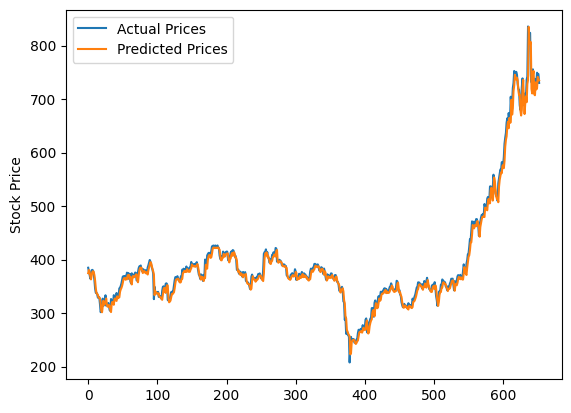

In [16]:
plt.plot(y_test_actual,label="Actual Prices")
plt.plot(pricited_prices,label="Predicted Prices")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


In [17]:
last_60_days = s_df[-60:]
last_60_days = np.reshape(last_60_days,(1,60,1))

future_prices = []
for i in range(10):
    next_price = model.predict(last_60_days)[0][0]
    future_prices.append(next_price)

    last_60_days = np.roll(last_60_days,-1,axis=1)
    last_60_days[0,-1,0] = next_price

future_prices = scaler.inverse_transform(np.array(future_prices).reshape(-1,1))

print("Predicted stock prices for next 10 days: ",future_prices.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted stock prices for next 10 days:  [716.7034  703.00146 691.033   680.4436  670.813   661.7966  653.18207
 644.8638  636.7994  628.97546]


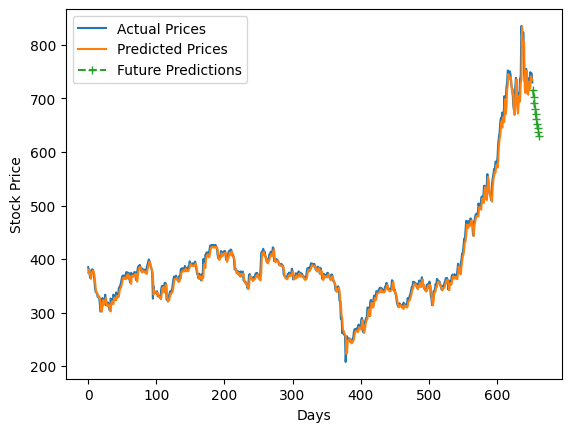

In [18]:
plt.plot(y_test_actual,label="Actual Prices")
plt.plot(pricited_prices,label="Predicted Prices")
future_days = list(range(len(y_test_actual),len(y_test_actual)+10))
plt.plot(future_days,future_prices,marker='+',ls='dashed',label="Future Predictions")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()
